In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pdb
from IPython.display import display
import os
import seaborn as sns
import statsmodels.formula.api as sm
from numpy.polynomial.polynomial import polyfit
from sklearn.model_selection import train_test_split
import sklearn
from math import sqrt
import glob

In [2]:
import ee
import geemap
service_account = ' boba-account@boba-430314.iam.gserviceaccount.com '
credentials = ee.ServiceAccountCredentials(service_account,'C:/Users/arj26323/OneDrive - University of Georgia/Documents/GEE AUTH/boba-430314-a19be859bfca.json')

ee.Initialize(credentials)

print(geemap.__version__)

0.34.1


In [3]:
##LOAD PREFORMATTED CSV - BE CAREFUL

df = pd.read_csv('C:/Users/arj26323/Documents/Data/Biomass datasets/Pennings/Final_df_interpolated/LOGO_df_interpolated.csv')

df['Sampling_year'] = df['Year']

In [4]:
##FILTERS

df0 = df.copy()
df0['Sampling_year'] = df0['Sampling_year'].astype(str)

##Including species
allplots_fc = pd.read_csv('C:/Users/arj26323/Documents/Data/Biomass datasets/Sapelo/GA_allplots_NEW.csv')
sp_df = allplots_fc[['Plant_Biomass', 'Longitude', 'Latitude', 'Species_Code', 'Year', 'Zone']]
dfx = pd.merge(df0, sp_df, on = ['Plant_Biomass', 'Latitude', 'Longitude', 'Year'], how = 'left')

df0 = dfx ##Careful with this circular object naming

df0['Plant_Biomass'] = np.where(df0['Year'] == 2002, df0['Plant_Biomass'] / 2, df0['Plant_Biomass']) 
##2002 data was doubled during extraction by mistake

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn import metrics
import numpy as np

seed = 3

yargs=df0['Plant_Biomass'] 

##best features
xargs = df0[['evi_max_05_10',
             'slope',
             'elevation',
             'Percent_flooding',
             'srad_peak',
             'dayl_Max',
             'nd_swir2_nir_mean_05_10',
             'ndvi_mean_08_10',
             'nd_r_g_max_05_10',
             'spei14d'
            ]]


# predictors / target
X = xargs
y = yargs
groups = df0['Site']

year_index = df0['Year']

features = xargs.columns

In [5]:
from sklearn.model_selection import GroupKFold, cross_validate
from scipy.stats import pearsonr
from sklearn.metrics import r2_score, mean_squared_error

gkf = GroupKFold(n_splits=10)

'''kf_groups = groups.loc[~test_mask]
'''

kf_groups = groups

# kf_groups= kf_groups.sample(frac = 1) ##check

'''for fold, (train_idx, val_idx) in enumerate(gkf.split(X_remaining, y_remaining, kf_groups)):

    train_x = X_remaining.iloc[train_idx]
    train_y = y_remaining.iloc[train_idx]
    
    val_x = X_remaining.iloc[val_idx]
    val_y = y_remaining.iloc[val_idx]
    
'''

train_rmses = []
val_rmses = []
pearsons = []
pearsons_training = []
importances_list = []
plot_data_list = []
train_counts = []
val_counts = []

exclude_sites = [7, 8] ##Remove these sites from analysis

for fold, (train_idx, val_idx) in enumerate(gkf.split(X, y, kf_groups)):
    
    train_groups = kf_groups.iloc[train_idx]
    val_groups = kf_groups.iloc[val_idx]
    
    val_groups_set = set(val_groups.unique())
    
    # Check if any excluded sites are in the current validation fold
    if any(site in val_groups_set for site in exclude_sites):
        print(f"\tSkipping Fold {fold} (contains excluded sites: {exclude_sites})")
        continue # Skip this iteration entirely
    
    train_x = X.iloc[train_idx]
    train_y = y.iloc[train_idx]
    
    val_x = X.iloc[val_idx]
    val_y = y.iloc[val_idx]

    print(f"\nFold {fold}:")
    print(f"\tTraining groups: {((train_groups)).unique()}")
    print(f"\tValidation groups: {((val_groups)).unique()}")
    
    estimator = RandomForestRegressor( ##TRY: n_est 500, minsplit 10, minleaf 25 or 30, max depth 7 or  10  (mayyybe 500 5 10 5)
        n_estimators=500,
        min_samples_split=10,
        min_samples_leaf=25,
        max_depth=7,
        random_state=seed
    )
#     estimator = sklearn.ensemble.GradientBoostingRegressor()
#     estimator = sklearn.neighbors.KNeighborsRegressor()
#     estimator = sklearn.linear_model.LinearRegression()
#     estimator = sklearn.svm.SVR()

    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('estimator', estimator)
    ])

    pipe.fit(train_x, train_y)
    
    train_pred_y = pipe.predict(train_x)
    val_pred_y = pipe.predict(val_x)
    
    train_rmse = np.sqrt(metrics.mean_squared_error(train_pred_y, train_y))
    val_rmse = np.sqrt(metrics.mean_squared_error(val_pred_y, val_y))
    
    r2 = r2_score(val_y, val_pred_y)
    r2_training = r2_score(train_y, train_pred_y)

    r_pears, p_value = pearsonr(val_y, val_pred_y)
    r_pears_training, p_value_training = pearsonr(train_y, train_pred_y)

    importances = pipe.named_steps['estimator'].feature_importances_
    
    t_count = len(train_pred_y)
    v_count = len(val_pred_y)
    
    # 2. Store training results ###
    train_df = pd.DataFrame({
        'Observed': train_y,
        'Predicted': train_pred_y,
        'Site': kf_groups.iloc[train_idx],
        'Type': 'Training'
    })
    
    # 3. Store validation (testing) results
    val_df = pd.DataFrame({
        'Observed': val_y,
        'Predicted': val_pred_y,
        'Site': kf_groups.iloc[val_idx],
        'Species': df0['Species_Code'].iloc[val_idx],  ##Species
        'Year': year_index.iloc[val_idx], # <--- Add this line
        'Type': 'Testing'
    })
    
    plot_data_list.extend([train_df, val_df]) ###
    
    print('\ttrain rmse:\t{:.2f}'.format(train_rmse))
    print('\tval rmse:\t{:.2f}'.format(val_rmse))
    print('\tr2:\t{:.2f}'.format(r2))
    print(f"\tPearson r: {r_pears:.2f}, p-value: {p_value:.3f}")
    print(f"\tPearson TRAIN r: {r_pears_training:.2f}, p-value TRAIN: {p_value_training:.3f}")

    
    train_rmses.append(train_rmse)
    val_rmses.append(val_rmse)
    pearsons.append(r_pears)
    pearsons_training.append(r_pears_training)
    importances_list.append(importances)
    train_counts.append(t_count)
    val_counts.append(v_count)

    

print('***')
print('mean train rmse:\t{:.2f}'.format(np.mean(train_rmses)))
print('mean val rmse:\t{:.2f}'.format(np.mean(val_rmses)))
print('mean pearson r:\t{:.2f}'.format(np.mean(pearsons)))
print('mean pearson r TRAIN:\t{:.2f}'.format(np.mean(pearsons_training)))

mean_importances = np.mean(importances_list, axis=0)
feature_names = X.columns
importance_df = pd.DataFrame({'feature': feature_names, 'importance': mean_importances})
print(importance_df.sort_values(by='importance', ascending=False))

print('count of samples TRAIN:\t{:.2f}'.format(np.mean(train_counts)))
print('count of samples VAL:\t{:.2f}'.format(np.mean(val_counts)))

all_results = pd.concat(plot_data_list).reset_index(drop=True)

print('\n***')
print('all_results check:')

# 1. Filter to only look at Validation ('Testing') results
val_results = all_results[all_results['Type'] == 'Testing']

# 2. Define a quick function to calculate RMSE for a given group
def calc_group_rmse(group):
    mse = metrics.mean_squared_error(group['Observed'], group['Predicted'])
    return np.sqrt(mse)

# 3. Group by Species and apply the calculation
species_rmse_df = val_results.groupby('Species').apply(calc_group_rmse).reset_index(name='RMSE')

print("\n--- Cross-Validated RMSE by Species ---")
print(species_rmse_df.sort_values(by='RMSE'))



Fold 0:
	Training groups: [8 7 9 6 5 4 3 2 1]
	Validation groups: [10]
	train rmse:	398.62
	val rmse:	414.55
	r2:	-0.63
	Pearson r: 0.27, p-value: 0.000
	Pearson TRAIN r: 0.79, p-value TRAIN: 0.000

Fold 1:
	Training groups: [ 8  7  9  6  5  4 10  3  1]
	Validation groups: [2]
	train rmse:	377.48
	val rmse:	532.86
	r2:	0.08
	Pearson r: 0.39, p-value: 0.000
	Pearson TRAIN r: 0.80, p-value TRAIN: 0.000

Fold 2:
	Training groups: [ 8  7  9  5  4 10  3  2  1]
	Validation groups: [6]
	train rmse:	386.96
	val rmse:	430.49
	r2:	0.41
	Pearson r: 0.67, p-value: 0.000
	Pearson TRAIN r: 0.78, p-value TRAIN: 0.000
	Skipping Fold 3 (contains excluded sites: [7, 8])

Fold 4:
	Training groups: [ 8  7  9  6  5  4 10  2  1]
	Validation groups: [3]
	train rmse:	393.44
	val rmse:	402.49
	r2:	-0.30
	Pearson r: 0.44, p-value: 0.000
	Pearson TRAIN r: 0.79, p-value TRAIN: 0.000

Fold 5:
	Training groups: [ 8  7  9  6  5 10  3  2  1]
	Validation groups: [4]
	train rmse:	396.22
	val rmse:	332.92
	r2:	0.23
	Pe

In [6]:
##2024 validation (peak and year gridmet, testing a theory that the spei14d is actually PEAK instead of YEAR)
val_peak = pd.read_csv('C:/Users/arj26323/Documents/All extract/2024_Validation/val_peak.csv')

##Renaming dayl_Max
val_peak['dayl_Max'] = val_peak['dayl_max']
peak_spei14d = val_peak['spei14d']
peak_val = val_peak['Plant_Biomass']

peak_xargs = val_peak[['evi_max_05_10',
             'slope',
             'elevation',
             'Percent_flooding',
             'srad_peak',
             'dayl_Max',
             'nd_swir2_nir_mean_05_10',
             'ndvi_mean_08_10',
             'nd_r_g_max_05_10',
             'spei14d']]

pred_valpeak = pipe.predict(peak_xargs)

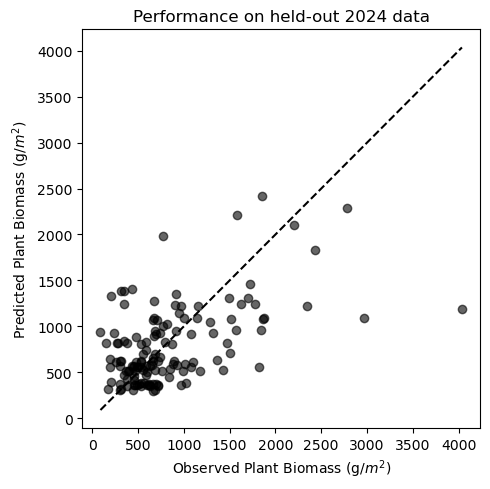

0.25046329031650094
PearsonRResult(statistic=0.5336326556750249, pvalue=2.242667134079666e-11)
528.2390477792493


In [7]:
##Testing

plt.figure(figsize=(5, 5))
plt.scatter(peak_val, pred_valpeak, alpha=0.6, color = 'black')
plt.plot(
    [peak_val.min(), peak_val.max()],
    [peak_val.min(), peak_val.max()],
    linestyle='--',
    color = 'black'
)
plt.xlabel('Observed Plant Biomass (g/$m^2$)')
plt.ylabel('Predicted Plant Biomass (g/$m^2$)')
plt.title('Performance on held-out 2024 data')
plt.tight_layout()


##Saving and displaying image
import os
output_dir = r'F:\Figures_PaperII'
file_name = 'testing2024.tif'

save_path = os.path.join(output_dir, file_name)

# plt.savefig(save_path, bbox_inches='tight', dpi=1000)

plt.show()

##Metrics
print(r2_score(peak_val, pred_valpeak))
print(pearsonr(peak_val, pred_valpeak))
print(np.sqrt(metrics.mean_squared_error(peak_val, pred_valpeak)))

In [8]:
sites=groups ##Added, from earlier

unique_sites = np.sort(sites.unique())

all_preds = []

for site in unique_sites:

    train_mask = sites != site
    test_mask  = sites == site

    X_train = X.loc[train_mask]
    y_train = y.loc[train_mask]
    X_test  = X.loc[test_mask]
    y_test  = y.loc[test_mask]

    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    
#     y_train_pred_x = pipe.predict(X_train) ##for plotting training data

    tmp = pd.DataFrame({
        'site': site,
        'observed': y_test.values,
        'predicted': y_pred
    })

    all_preds.append(tmp)

pred_df = pd.concat(all_preds, ignore_index=True)


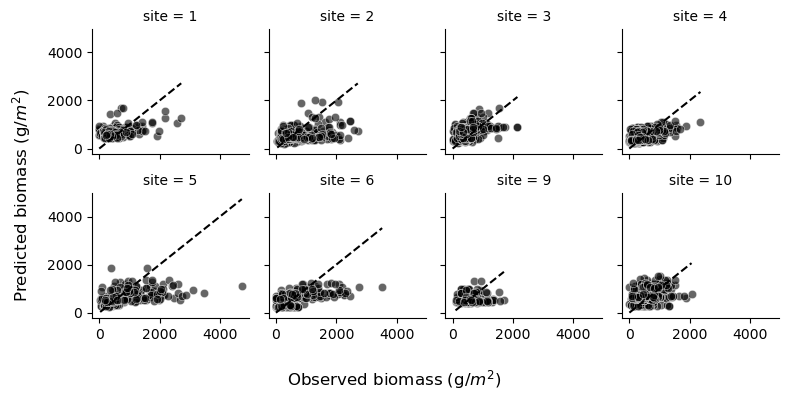

In [9]:
##VALIDATION plotting
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)


import seaborn as sns

target_sites = [1, 2, 3, 4, 5, 6, 9, 10]
plot_df = pred_df[pred_df['site'].isin(target_sites)]
# plot_df = pred_df

g = sns.FacetGrid(plot_df, col="site", col_wrap=4, height=2, sharex=True, sharey=True)
g.map_dataframe(sns.scatterplot, x="observed", y="predicted", alpha=0.6, color = 'black')
g.map_dataframe(
    lambda data, **kws: plt.plot(
        [data.observed.min(), data.observed.max()],
        [data.observed.min(), data.observed.max()],
        linestyle='--',
        color = 'black'
    )
)

# g.set_axis_labels("Observed biomass (g/$m^2$)", "Predicted biomass (g/$m^2$)")


# Remove per-axis labels
g.set_axis_labels("", "")

# Add shared labels
g.figure.supxlabel("Observed biomass (g/$m^2$)")
g.figure.supylabel("Predicted biomass (g/$m^2$)")

g.tight_layout()

##Saving and displaying image
import os
output_dir = r'F:\Figures_PaperII'
file_name = 'validation_allsites.tif'

save_path = os.path.join(output_dir, file_name)

# plt.savefig(save_path, bbox_inches='tight', dpi=300)
plt.show()


C:\Users\arj26323\AppData\Local\Temp\ipykernel_15496\3704998008.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  all_results_x['Cat'] = np.where(all_results_x['Type'] == 'Testing', 'Validation', all_results_x['Type'])


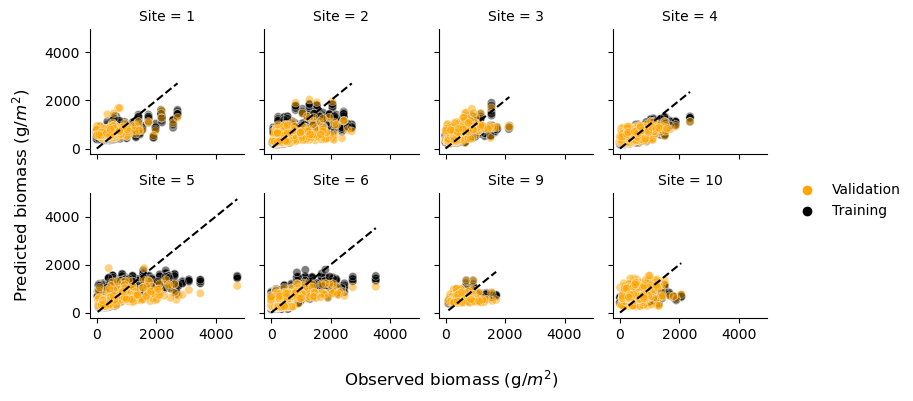

In [10]:
##TRAINIng plotting

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

target_sites = [1, 2, 3, 4, 5, 6, 9, 10]
all_results_x = all_results[all_results['Site'].isin(target_sites)]
all_results_x['Cat'] = np.where(all_results_x['Type'] == 'Testing', 'Validation', all_results_x['Type'])
# all_results_x = all_results

all_training = all_results_x[all_results_x['Type'] == 'Training']
all_testing = all_results_x[all_results_x['Type'] == 'Testing']

all_results_x = all_results_x.sort_values('Cat')

my_colors = ["orange", "black"]
cat_order = ['Validation', 'Training']

g = sns.FacetGrid(all_results_x, col="Site", col_wrap=4, height=2, sharex=True, sharey=True)
g.map_dataframe(sns.scatterplot, 
                x="Observed", 
                y="Predicted",
                hue = 'Cat', 
#                 style = 'Cat',
                hue_order=cat_order,
                alpha=0.5, 
                palette=my_colors
               )

# g = sns.FacetGrid(all_training, col="Site", col_wrap=4, height=2, sharex=True, sharey=True)
# g.map_dataframe(sns.scatterplot, x="Observed", y="Predicted", alpha=0.6, size = 1, color = 'black', palette=my_colors)
g.map_dataframe(
    lambda data, **kws: plt.plot(
        [data.Observed.min(), data.Observed.max()],
        [data.Observed.min(), data.Observed.max()],
        linestyle='--',
        color = 'black'
    )
)

# g.set_axis_labels("Observed biomass (g/$m^2$)", "Predicted biomass (g/$m^2$)")


# Remove per-axis labels
g.set_axis_labels("", "")

g.add_legend()

# Add shared labels
g.figure.supxlabel("Observed biomass (g/$m^2$)")
g.figure.supylabel("Predicted biomass (g/$m^2$)")

g.tight_layout()

##Saving and displaying image
import os
output_dir = r'F:\Figures_PaperII'
file_name = 'training_testing_final.tif'

save_path = os.path.join(output_dir, file_name)

# plt.savefig(save_path, bbox_inches='tight', dpi=1000)
plt.show()



In [42]:
#Finito